In [1]:
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO

import os
import cv2
import torch
import torchvision
import torchvision.transforms as T
import numpy as np
from tqdm import tqdm

# Define transformations (optional)
import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch.nn as nn
import torch.nn.functional as F

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.2 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:

# Path to the annotation file
annotation_file = "/kaggle/input/segmentation-dataset/result.json"
image_folder = "/kaggle/input/segmentation-dataset/"

# Load COCO annotations
coco = COCO(annotation_file)

# Get all image IDs
image_ids = coco.getImgIds()

class COCOSegmentationDataset(Dataset):
    def __init__(self, coco, image_folder, transforms=None):
        self.coco = coco
        self.image_folder = image_folder
        self.image_ids = coco.getImgIds()
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id, iscrowd=False)
        annotations = self.coco.loadAnns(ann_ids)
        
        # Load image
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.image_folder, img_info["file_name"])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Apply transformations
        if self.transforms:
            transformed = self.transforms(image=image)
            image = transformed['image']
        else:
            image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        
        # Create segmentation mask
        mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)
        boxes = []
        labels = []
        
        for ann in annotations:
            segmentation = ann["segmentation"]
            for seg in segmentation:
                pts = np.array(seg, dtype=np.int32).reshape(-1, 2)
                cv2.fillPoly(mask, [pts], color=1)
            
            # Get bounding box
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])
        
        # Convert boxes and labels to tensors
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        mask = torch.tensor(mask, dtype=torch.uint8)
        
        # Handle empty annotations
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            mask = torch.zeros((img_info["height"], img_info["width"]), dtype=torch.uint8)
        
        # Correct box shape handling
        boxes = boxes.view(-1, 4)  # Ensure shape is [N, 4]
        
        # Create target dictionary
        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": mask.unsqueeze(0),  # Add batch dimension
        }
        
        return image, target

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [3]:
transform = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

# Create dataset instance
dataset = COCOSegmentationDataset(coco, image_folder, transforms=transform)

train_loader = DataLoader(
    dataset, 
    batch_size=1, 
    shuffle=True, 
    num_workers=2,  # Use >0 for parallel data loading
    pin_memory=True  # Optimizes memory transfer for GPU training
)


In [4]:
model_path = '/kaggle/input/ecg-object-detection-model/pytorch/default/1/trained_ecg_object_detection_model.pth'
num_classes = 2 # 1 class (ECG) + background 

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

# modify weights to pre-trained ones
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
model.load_state_dict(torch.load(model_path))

# Convert from objection detection to segmentation

# Load a Mask R-CNN model with the same backbone
mask_model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights='DEFAULT')

# Copy the trained Faster R-CNN backbone
mask_model.backbone = model.backbone

# Copy the trained box predictor (classification head)
mask_model.roi_heads.box_predictor = model.roi_heads.box_predictor

# Modify the mask head for segmentation (depends on dataset)
in_features_mask = mask_model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256  # Default value in Mask R-CNN
mask_model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask, hidden_layer, num_classes
)

<ipython-input-4-916dff75f08e>:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


In [5]:
# Move to GPU if available
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
mask_model.to(device)
print(f"Device: {device}")

Device: cuda


In [6]:
def train_model(model, dataloader, optimizer, num_epochs=10, device="cuda"):
    model.to(device)  # Move model to the correct device
    model.train()  # Set model to training mode
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
        
        for images, targets in progress_bar:
            # Move images to the correct device
            images = [img.to(device) for img in images]

            # Squeeze unnecessary dimensions for boxes, labels, and masks
            if len(targets["boxes"]) > 0:
                targets["boxes"] = targets["boxes"].squeeze(0)  # Remove batch dimension
                if targets["boxes"].dim() == 1:  # If we end up with a 1D tensor, reshape to [1, 4]
                    targets["boxes"] = targets["boxes"].unsqueeze(0)  # Ensure shape is [1, 4]

                targets["labels"] = targets["labels"].squeeze(0)
                if targets["labels"].dim() == 0:  # If it's a scalar, reshape to [1]
                    targets["labels"] = targets["labels"].unsqueeze(0)

                targets["masks"] = targets["masks"].squeeze(0)
                if targets["masks"].dim() == 2:  # If the mask is 2D, ensure it has the proper batch dimension
                    targets["masks"] = targets["masks"].unsqueeze(0)  # Ensure shape is [1, H, W]
            else:
                print("No bounding boxes in this target!")

            # Move targets to the correct device
            targets = {k: v.to(device) for k, v in targets.items()}

            # Forward pass: Get the loss
            loss_dict = model(images, [targets])  # Wrap targets into a list for a single batch
            loss = sum(loss for loss in loss_dict.values())

            # Backward pass: Compute gradients
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track the loss
            epoch_loss += loss.item()
            progress_bar.set_postfix(loss=epoch_loss / len(dataloader))
        
        # Print epoch loss
        print(f"Epoch {epoch+1} finished with loss: {epoch_loss / len(dataloader):.4f}")
    
    print("Training complete!")


In [7]:
 # Define optimizer
optimizer = torch.optim.Adam(mask_model.parameters(), lr=0.0001)

# Train model
train_model(mask_model, train_loader, optimizer, num_epochs=2, device=device)

Epoch 1/2: 100%|██████████| 90/90 [00:30<00:00,  2.93it/s, loss=0.0555]


Epoch 1 finished with loss: 0.0555


Epoch 2/2: 100%|██████████| 90/90 [00:30<00:00,  3.00it/s, loss=0.0169] 

Epoch 2 finished with loss: 0.0169
Training complete!


In [8]:
torch.save(mask_model.state_dict(), "ecg_segmentation_model.pth")


Test model on new image

In [54]:
import matplotlib.pyplot as plt
from torchvision import transforms

mask_model.eval()

# Load and preprocess the image
# image_path = "/kaggle/input/practice-images/train_000152.png"
image_path = "/kaggle/input/practice-images/train_000998.png"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

transform = transforms.Compose([
    transforms.ToTensor(),
])
input_tensor = transform(image).unsqueeze(0)

# Run inference
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_tensor = input_tensor.to(device)

with torch.no_grad():
    output = mask_model(input_tensor)


In [55]:
# Assuming `outputs` is the model's output
boxes = output[0]['boxes'].cpu().numpy()  # Convert to numpy array
scores = output[0]['scores'].cpu().numpy()  # Confidence scores
labels = output[0]['labels'].cpu().numpy()  # Class labels

In [56]:
boxes

array([], shape=(0, 4), dtype=float32)

In [57]:
# Convert image tensor to numpy array
image = input_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()

# If the image is normalized, scale it back to [0, 255] range
if image.max() <= 1.0:
    image = (image * 255).astype(np.uint8)

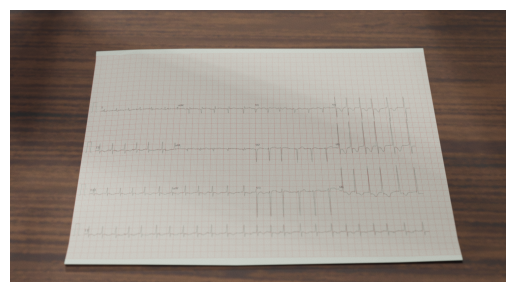

In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a plot
fig, ax = plt.subplots(1)
ax.imshow(image)

# Plot each bounding box
for box in boxes:
    xmin, ymin, xmax, ymax = box
    width = xmax - xmin
    height = ymax - ymin

    # Create a rectangle patch
    rect = patches.Rectangle(
        (xmin, ymin), width, height,
        linewidth=2, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)

# Show the plot
plt.axis("off")
plt.show()